In [ ]:
!pip install pystac-client planetary-computer xarray netcdf4
!pip install contextily
!pip install netcdf4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import requests
import os
import warnings
import scipy.ndimage as ndimage


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import requests
import numpy as np
import pandas as pd
import xarray as xr
import pystac_client
import planetary_computer
from google.colab import drive

# ==============================================================================
# 0. CONECTAR A GOOGLE DRIVE
# ==============================================================================
drive.mount('/content/drive')

# ==============================================================================
# 1. CONFIGURACIÓN DEL PROYECTO
# ==============================================================================
FECHA_INICIO = "2019-12-01"
FECHA_FIN = "2019-12-31"

# Ruta de guardado en tu Drive
CARPETA_DRIVE = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/"
if not os.path.exists(CARPETA_DRIVE):
    os.makedirs(CARPETA_DRIVE)

ARCHIVO_SALIDA = os.path.join(CARPETA_DRIVE, f"TROPOMI_Madrid_{FECHA_INICIO[:7].replace('-','_')}.csv")

# Coordenadas de interés (Valdemingómez/Madrid)
LAT_CENTRO, LON_CENTRO = 40.3311, -3.5800 # Corregido a Madrid
MARGEN = 0.5  # Grados de margen alrededor del punto
LAT_MIN, LAT_MAX = LAT_CENTRO - MARGEN, LAT_CENTRO + MARGEN
LON_MIN, LON_MAX = LON_CENTRO - MARGEN, LON_CENTRO + MARGEN

archivo_temporal = "temp_tropomi.nc"

# ==============================================================================
# 2. PROCESAMIENTO DÍA A DÍA
# ==============================================================================
print(f"🚀 Iniciando recolección: {FECHA_INICIO} al {FECHA_FIN}")
dias_rango = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN)
lista_datos_acumulados = []

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

for fecha in dias_rango:
    dia_str = fecha.strftime("%Y-%m-%d")
    print(f"\n📅 Analizando: {dia_str}")

    try:
        # Búsqueda en STAC
        busqueda = catalog.search(
            collections=["sentinel-5p-l2-netcdf"],
            bbox=[LON_MIN, LAT_MIN, LON_MAX, LAT_MAX],
            datetime=f"{dia_str}/{dia_str}"
        )

        items = [item for item in list(busqueda.items()) if "ch4" in item.assets]

        if not items:
            print(f"    ☁️ Sin datos (nubes o sin pasada).")
            continue

        # Tomamos la pasada más relevante
        item = items[0]
        hora_utc = item.datetime
        url = planetary_computer.sign(item).assets["ch4"].href

        # Descarga rápida
        r = requests.get(url, stream=True, timeout=60)
        with open(archivo_temporal, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk: f.write(chunk)

        # Lectura de variables
        ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="netcdf4")
        ds_sup = xr.open_dataset(archivo_temporal, group="PRODUCT/SUPPORT_DATA/INPUT_DATA", engine="netcdf4")

        lats = ds.latitude.values[0]
        lons = ds.longitude.values[0]
        ch4_corr = ds.methane_mixing_ratio_bias_corrected.values[0]
        ch4_raw = ds.methane_mixing_ratio.values[0]
        qa = ds.qa_value.values[0]
        aire = ds_sup.dry_air_subcolumns.values[0].sum(axis=-1)

        ds.close(); ds_sup.close(); os.remove(archivo_temporal)

        # Obtención de Viento ERA5
        url_vnt = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT_CENTRO}&longitude={LON_CENTRO}&start_date={dia_str}&end_date={dia_str}&hourly=wind_speed_10m,wind_direction_10m&wind_speed_unit=ms"
        res_vnt = requests.get(url_vnt).json()
        h_idx = hora_utc.hour
        v_vel = res_vnt['hourly']['wind_speed_10m'][h_idx]
        v_dir = res_vnt['hourly']['wind_direction_10m'][h_idx]

        # Cálculo de componentes
        u10 = -v_vel * np.sin(np.radians(v_dir))
        v10 = -v_vel * np.cos(np.radians(v_dir))

        # --- FILTRADO INTELIGENTE ---
        mask_espacial = (lats >= LAT_MIN) & (lats <= LAT_MAX) & (lons >= LON_MIN) & (lons <= LON_MAX)
        mask_nubes = ~np.isnan(ch4_corr)
        mask = mask_espacial & mask_nubes

        if not np.any(mask):
            print(f"    ⚠️ Día descartado: Todo nubes (NaN).")
            continue

        # DATAFRAME SIN ANOMALÍA
        df_dia = pd.DataFrame({
            'timestamp': hora_utc,
            'lat': lats[mask],
            'lon': lons[mask],
            'metano_ppb': ch4_corr[mask],
            'metano_raw_ppb': ch4_raw[mask],
            'columna_aire': aire[mask],
            'qa_value': qa[mask],
            'u10': u10,
            'v10': v10,
            'v_modulo': v_vel
        })

        if (df_dia['metano_ppb'] == 0).all() or len(df_dia) < 10:
            print(f"    ⚠️ Día descartado por datos corruptos o insuficientes.")
            continue

        lista_datos_acumulados.append(df_dia)
        print(f"    ✅ Éxito: {len(df_dia)} píxeles guardados.")

    except Exception as e:
        print(f"    ❌ Error procesando el día: {e}")

# ==============================================================================
# 3. CONSOLIDACIÓN Y EXPORTACIÓN
# ==============================================================================
if lista_datos_acumulados:
    df_final = pd.concat(lista_datos_acumulados, ignore_index=True)
    df_final.to_csv(ARCHIVO_SALIDA, index=False)
    print("\n" + "="*60)
    print(f"🏁 PROCESO FINALIZADO")
    print(f"📁 Archivo: {ARCHIVO_SALIDA}")
    print(f"📊 Total de píxeles válidos en el mes: {len(df_final)}")
    print("="*60)
else:
    print("\n😭 No se pudo recolectar ningún dato válido para este periodo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Iniciando recolección: 2019-12-01 al 2019-12-31

📅 Analizando: 2019-12-01
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 2019-12-02
    ✅ Éxito: 60 píxeles guardados.

📅 Analizando: 2019-12-03
    ✅ Éxito: 72 píxeles guardados.

📅 Analizando: 2019-12-04
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 2019-12-05
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 2019-12-06
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 2019-12-07
    ❌ Error procesando el día: The request exceeded the maximum allowed time, please try again. If the issue persists, please contact planetarycomputer@microsoft.com.



📅 Analizando: 2019-12-08
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 2019-12-09
    ⚠️ Día descartado por datos corruptos o insuficientes.

📅 Analizando: 2019-12-10
    ⚠️ Día descartado: Todo nubes (NaN).

📅 Analizando: 20

# Descarga dí apluma emit

Buscando datos de TROPOMI para el día 2023-02-24...
Encontrada(s) 1 pasada(s) satelital(es). Descargando la primera...

Descargando NetCDF...
Procesando matrices...
Generando visualización...


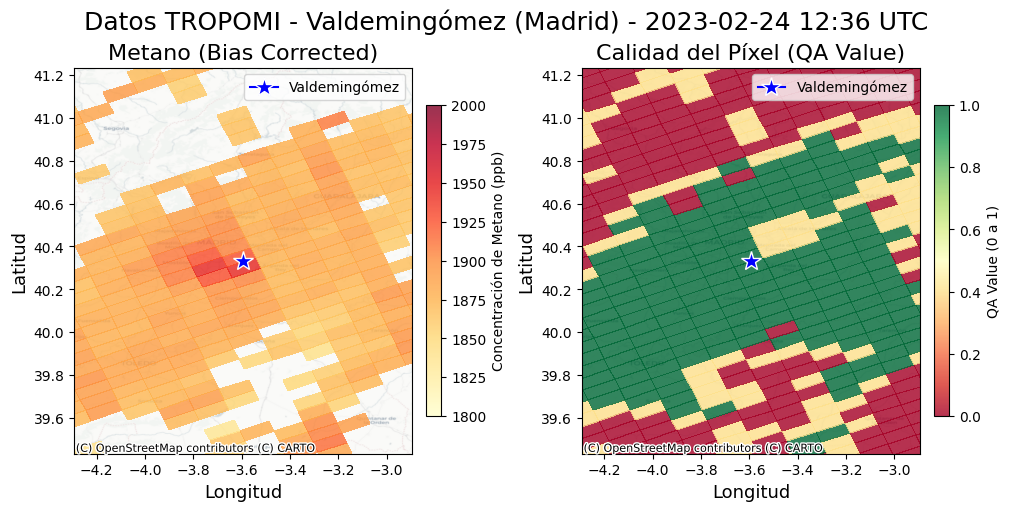

¡Proceso completado!
¡Proceso completado!


In [ ]:

warnings.filterwarnings("ignore")



# ==============================================================================
# 1. CONFIGURACIÓN DEL ESPACIO Y FECHA
# ==============================================================================
# Fecha exacta que has solicitado
FECHA = "2023-02-24"

# Coordenadas aproximadas del vertedero de Valdemingómez (Madrid)
LAT_CENTRO = 40.334
LON_CENTRO = -3.593

# Definimos el margen del mapa (ajusta este valor para hacer más o menos zoom)
MARGEN_LAT = 0.9
MARGEN_LON = 0.7

LAT_MIN, LAT_MAX = LAT_CENTRO - MARGEN_LAT, LAT_CENTRO + MARGEN_LAT
LON_MIN, LON_MAX = LON_CENTRO - MARGEN_LON, LON_CENTRO + MARGEN_LON

archivo_temporal = "temp_dia_ch4.nc"

# ==============================================================================
# 2. BÚSQUEDA EN EL CATÁLOGO
# ==============================================================================
print(f"Buscando datos de TROPOMI para el día {FECHA}...")

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Buscamos margen de 2 días para asegurar capturar la pasada UTC correcta
busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    bbox=[LON_MIN, LAT_MIN, LON_MAX, LAT_MAX],
    datetime=f"{FECHA}/{FECHA}"
)

items_brutos = list(busqueda.items())
items = [item for item in items_brutos if "ch4" in item.assets]

if len(items) == 0:
    print("No se encontraron pasadas satelitales para ese día y región.")
else:
    print(f"Encontrada(s) {len(items)} pasada(s) satelital(es). Descargando la primera...\n")

    item = items[0] # Tomamos la primera pasada del día
    item_firmado = planetary_computer.sign(item)
    url = item_firmado.assets["ch4"].href
    hora_pasada = item.datetime

    # Descarga del archivo NetCDF
    print("Descargando NetCDF...")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(archivo_temporal, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    # ==============================================================================
    # 3. EXTRACCIÓN DE LAS MATRICES 2D
    # ==============================================================================
    print("Procesando matrices...")
    ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="netcdf4")
    ds_support = xr.open_dataset(archivo_temporal, group="PRODUCT/SUPPORT_DATA/INPUT_DATA", engine="netcdf4")

    # Extraemos matrices completas (conservando la estructura 2D de la pasada del satélite)
    lats = ds.latitude.values[0]
    lons = ds.longitude.values[0]
    metano = ds.methane_mixing_ratio_bias_corrected.values[0]
    calidad = ds.qa_value.values[0]

    # La columna de aire seco tiene niveles atmosféricos, la sumamos para obtener el total 2D
    aire_seco = ds_support.dry_air_subcolumns.values[0].sum(axis=-1)

    # Limpieza
    ds.close()
    ds_support.close()
    os.remove(archivo_temporal)

    # ==============================================================================
    # 4. REPRESENTACIÓN EN RASTER (2 GRÁFICAS)
    # ==============================================================================
    print("Generando visualización...")

    # Cambiamos a 1 fila y 2 columnas (1, 2)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    fig.suptitle(f"Datos TROPOMI - Valdemingómez (Madrid) - {hora_pasada.strftime('%Y-%m-%d %H:%M UTC')}", fontsize=18)

    # Eliminamos la tupla de 'aire_seco' de la lista
    variables = [
        # (Datos, Mapa de color, Etiqueta, Título, vmin, vmax)
        (metano, 'YlOrRd', 'Concentración de Metano (ppb)', 'Metano (Bias Corrected)', 1800, 2000),
        (calidad, 'RdYlGn', 'QA Value (0 a 1)',  'Calidad del Píxel (QA Value)', 0, 1)
    ]

    for ax, (data_matrix, cmap, cb_label, title, v_min, v_max) in zip(axes, variables):
        mesh = ax.pcolormesh(
            lons, lats, data_matrix,
            cmap=cmap,
            vmin=v_min,
            vmax=v_max,
            shading='auto',
            alpha=0.8,
            edgecolor='none'
        )

        plt.colorbar(mesh, ax=ax, label=cb_label, fraction=0.046, pad=0.04)

        # Marcamos el centro de Valdemingómez
        ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='blue', markersize=15,
                markeredgecolor='white', label="Valdemingómez", zorder=5)

        # Centramos la cámara
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)

        # Añadimos el mapa base
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

        ax.set_title(title, fontsize=16)
        ax.set_xlabel("Longitud",fontsize=13 )
        ax.set_ylabel("Latitud", fontsize=13)
        ax.legend()

    plt.show()
    print("¡Proceso completado!")

    plt.show()
    print("¡Proceso completado!")

In [ ]:
# 4. REPRESENTACIÓN EN RASTER (2 GRÁFICAS)
    # ==============================================================================
    print("Generando visualización...")

    # Cambiamos a 1 fila y 2 columnas (1, 2)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
    fig.suptitle(f"Datos TROPOMI - Valdemingómez (Madrid) - {hora_pasada.strftime('%Y-%m-%d %H:%M UTC')}", fontsize=18)

    # Eliminamos la tupla de 'aire_seco' de la lista
    variables = [
        # (Datos, Mapa de color, Etiqueta, Título, vmin, vmax)
        (metano, 'YlOrRd', 'Concentración de Metano (ppb)', 'Metano (Bias Corrected)', 1800, 2000),
        (calidad, 'RdYlGn', 'QA Value (0 a 1)', 'Calidad del Píxel (QA Value)', 0, 1)
    ]

    for ax, (data_matrix, cmap, cb_label, title, v_min, v_max) in zip(axes, variables):
        mesh = ax.pcolormesh(
            lons, lats, data_matrix,
            cmap=cmap,
            vmin=v_min,
            vmax=v_max,
            shading='auto',
            alpha=0.8,
            edgecolor='none'
        )

        plt.colorbar(mesh, ax=ax, label=cb_label, fraction=0.046, pad=0.04)

        # Marcamos el centro de Valdemingómez
        ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='blue', markersize=15,
                markeredgecolor='white', label="Valdemingómez", zorder=5)

        # Centramos la cámara
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)

        # Añadimos el mapa base
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

        ax.set_title(title, fontsize=16)
        ax.set_xlabel("Longitud", fontsize=15 )
        ax.set_ylabel("Latitud", fontsize=15 )
        ax.legend()

    plt.show()
    print("¡Proceso completado!")



IndentationError: unexpected indent (3672432924.py, line 3)

Buscando datos de TROPOMI para el día 2023-02-24...
Descargando archivo NetCDF...
Extrayendo variables...
Generando visualización...


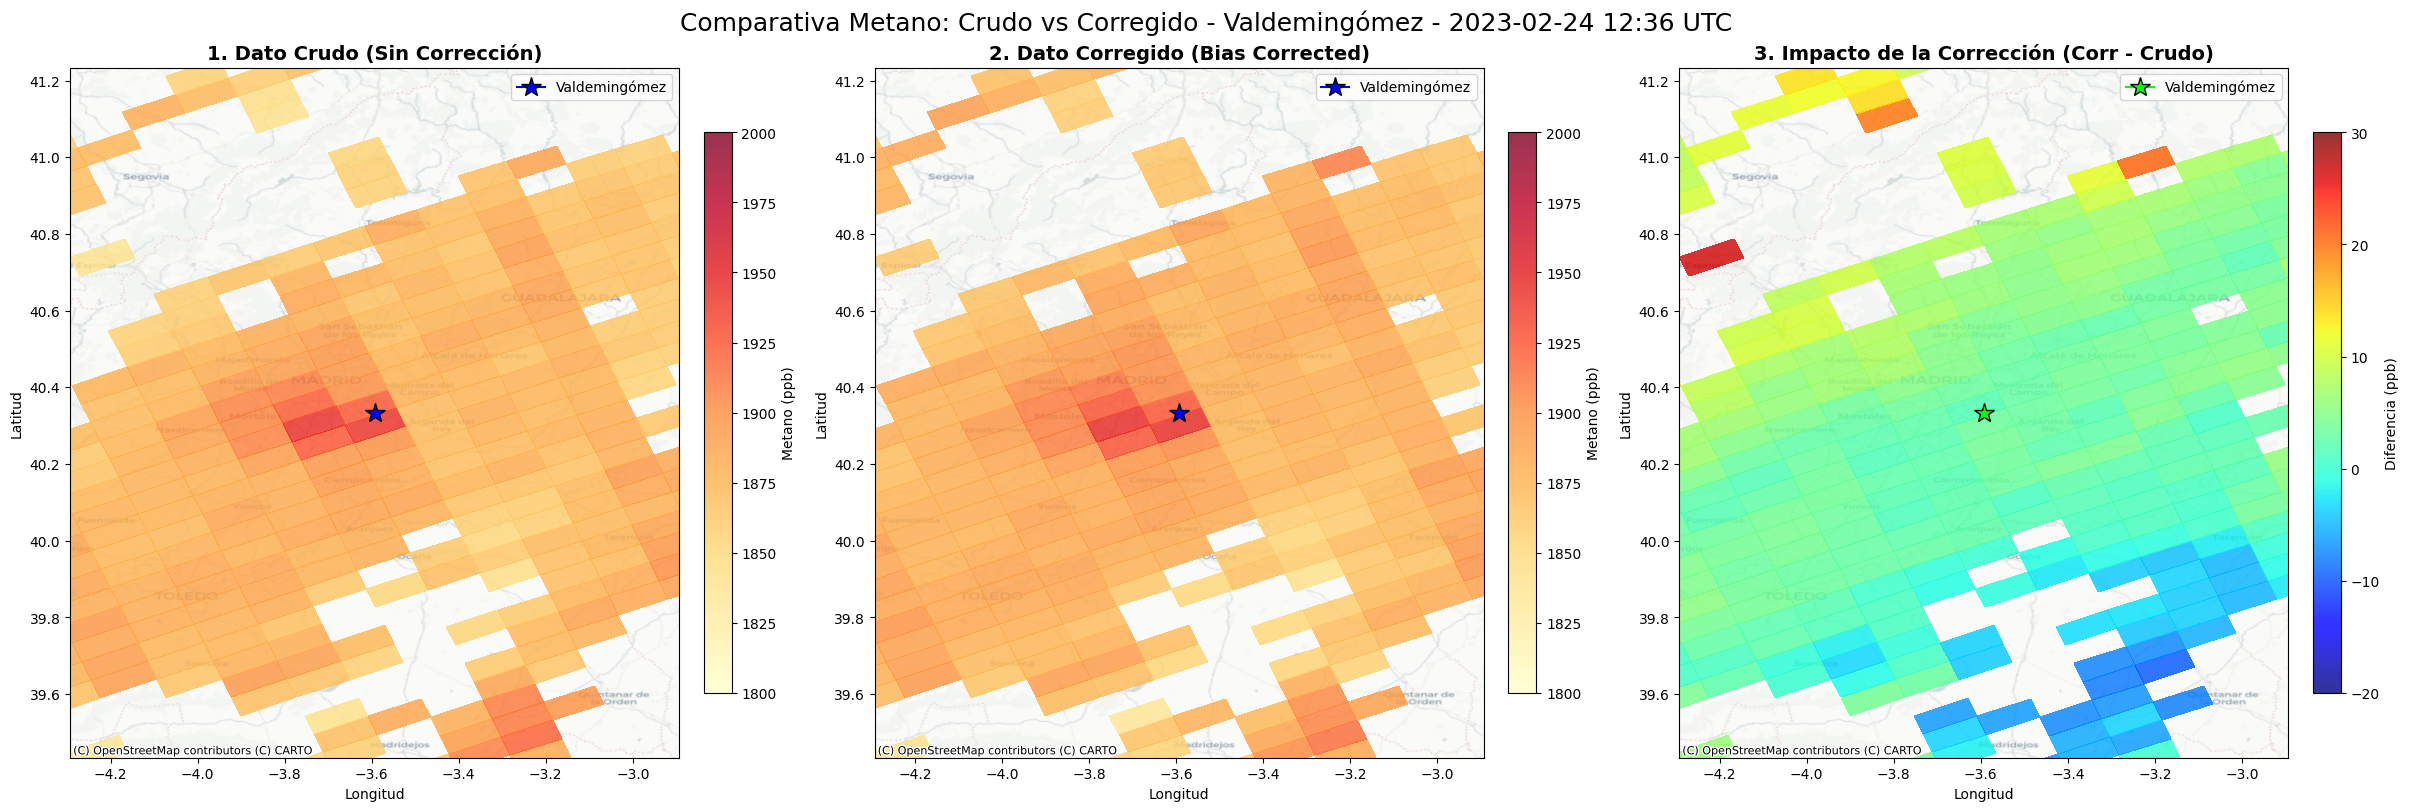

¡Proceso completado!


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import requests
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer
import contextily as cx

# ==============================================================================
# 1. CONFIGURACIÓN DEL ESPACIO Y FECHA
# ==============================================================================
FECHA = "2023-02-24"
LAT_CENTRO = 40.334  # Valdemingómez
LON_CENTRO = -3.593

# Definimos el margen del mapa (ajusta este valor para hacer más o menos zoom)
MARGEN_LAT = 0.9
MARGEN_LON = 0.7

LAT_MIN, LAT_MAX = LAT_CENTRO - MARGEN_LAT, LAT_CENTRO + MARGEN_LAT
LON_MIN, LON_MAX = LON_CENTRO - MARGEN_LON, LON_CENTRO + MARGEN_LON
archivo_temporal = "temp_dia_ch4_comparativa.nc"

# ==============================================================================
# 2. BÚSQUEDA Y DESCARGA DEL DATO
# ==============================================================================
print(f"Buscando datos de TROPOMI para el día {FECHA}...")

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

busqueda = catalog.search(
    collections=["sentinel-5p-l2-netcdf"],
    bbox=[LON_MIN, LAT_MIN, LON_MAX, LAT_MAX],
    datetime=f"{FECHA}/{FECHA}"
)

items_brutos = list(busqueda.items())
items = [item for item in items_brutos if "ch4" in item.assets]

if len(items) == 0:
    print("No se encontraron pasadas satelitales para ese día y región.")
else:
    item = items[0]
    item_firmado = planetary_computer.sign(item)
    url = item_firmado.assets["ch4"].href
    hora_pasada = item.datetime

    print("Descargando archivo NetCDF...")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(archivo_temporal, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    # ==============================================================================
    # 3. EXTRACCIÓN DE LAS DOS VERSIONES DEL METANO
    # ==============================================================================
    print("Extrayendo variables...")
    ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="netcdf4")

    lats = ds.latitude.values[0]
    lons = ds.longitude.values[0]

    # 1. Dato Crudo
    metano_crudo = ds.methane_mixing_ratio.values[0]

    # 2. Dato Corregido (Bias Corrected)
    metano_corregido = ds.methane_mixing_ratio_bias_corrected.values[0]

    # 3. Calculamos la diferencia matemática entre ambos
    diferencia = metano_corregido - metano_crudo

    ds.close()
    os.remove(archivo_temporal)

    # ==============================================================================
    # 4. REPRESENTACIÓN EN 3 GRÁFICAS (RASTER)
    # ==============================================================================
    print("Generando visualización...")
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
    fig.suptitle(f"Comparativa Metano: Crudo vs Corregido - Valdemingómez - {hora_pasada.strftime('%Y-%m-%d %H:%M UTC')}", fontsize=18)

    # Lista con las 3 variables a pintar.
    # Mantenemos los límites de 1700 a 2000 en las dos primeras.
    variables = [
        (metano_crudo, 'YlOrRd', 'Metano (ppb)', '1. Dato Crudo (Sin Corrección)', 1800, 2000),
        (metano_corregido, 'YlOrRd', 'Metano (ppb)', '2. Dato Corregido (Bias Corrected)', 1800, 2000),
        (diferencia, 'jet', 'Diferencia (ppb)', '3. Impacto de la Corrección (Corr - Crudo)', -20, 30)
        # En la diferencia usamos 'bwr' (Blue-White-Red) y dejamos los límites en None para que se autoajuste.
    ]

    for ax, (data_matrix, cmap, cb_label, title, v_min, v_max) in zip(axes, variables):

        # Pcolormesh respeta la rejilla real de TROPOMI
        mesh = ax.pcolormesh(
            lons, lats, data_matrix,
            cmap=cmap,
            vmin=v_min, vmax=v_max,
            shading='auto', alpha=0.8, edgecolor='none'
        )

        plt.colorbar(mesh, ax=ax, label=cb_label, fraction=0.046, pad=0.04)

        # Estrella de Valdemingómez
        ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime' if title.startswith('3') else 'blue',
                markersize=15, markeredgecolor='black', label="Valdemingómez", zorder=5)

        # Zoom a la zona
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)

        # Mapa base por debajo
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.legend()

    plt.show()
    print("¡Proceso completado!")

# DESCARGAR DATOS. PRIMER CODIGO OCN FILTROS

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

# ==============================================================================
# 0. CONECTAR A GOOGLE DRIVE
# ==============================================================================
drive.mount('/content/drive')

# ==============================================================================
# 1. CONFIGURACIÓN DEL PROYECTO
# ==============================================================================
# Ajusta el mes que quieras procesar aquí:
FECHA_INICIO = "2023-04-01"
FECHA_FIN = "2023-04-30"

# Ruta de guardado en tu Drive
CARPETA_DRIVE = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/"
if not os.path.exists(CARPETA_DRIVE):
    os.makedirs(CARPETA_DRIVE)

ARCHIVO_SALIDA = os.path.join(CARPETA_DRIVE, f"TROPOMI_Tenerife_{FECHA_INICIO[:7].replace('-','_')}.csv")

# Coordenadas de interés (Valdemingómez/Madrid)
LAT_CENTRO, LON_CENTRO = 28.11769, -16.48005
MARGEN = 0.5  # Grados de margen alrededor del punto
LAT_MIN, LAT_MAX = LAT_CENTRO - MARGEN, LAT_CENTRO + MARGEN
LON_MIN, LON_MAX = LON_CENTRO - MARGEN, LON_CENTRO + MARGEN

archivo_temporal = "temp_tropomi.nc"

# ==============================================================================
# 2. PROCESAMIENTO DÍA A DÍA
# ==============================================================================
print(f"🚀 Iniciando recolección: {FECHA_INICIO} al {FECHA_FIN}")
dias_rango = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN)
lista_datos_acumulados = []

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

for fecha in dias_rango:
    dia_str = fecha.strftime("%Y-%m-%d")
    print(f"\n📅 Analizando: {dia_str}")

    try:
        # Búsqueda en STAC
        busqueda = catalog.search(
            collections=["sentinel-5p-l2-netcdf"],
            bbox=[LON_MIN, LAT_MIN, LON_MAX, LAT_MAX],
            datetime=f"{dia_str}/{dia_str}"
        )

        items = [item for item in list(busqueda.items()) if "ch4" in item.assets]

        if not items:
            print(f"   ☁️ Sin datos (nubes o sin pasada).")
            continue

        # Tomamos la pasada más relevante
        item = items[0]
        hora_utc = item.datetime
        url = planetary_computer.sign(item).assets["ch4"].href

        # Descarga rápida
        r = requests.get(url, stream=True, timeout=60)
        with open(archivo_temporal, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024): # 1MB chunks
                if chunk: f.write(chunk)

        # Lectura de variables
        ds = xr.open_dataset(archivo_temporal, group="PRODUCT", engine="netcdf4")
        ds_sup = xr.open_dataset(archivo_temporal, group="PRODUCT/SUPPORT_DATA/INPUT_DATA", engine="netcdf4")

        lats = ds.latitude.values[0]
        lons = ds.longitude.values[0]
        ch4_corr = ds.methane_mixing_ratio_bias_corrected.values[0]
        ch4_raw = ds.methane_mixing_ratio.values[0]
        qa = ds.qa_value.values[0]
        aire = ds_sup.dry_air_subcolumns.values[0].sum(axis=-1)

        ds.close(); ds_sup.close(); os.remove(archivo_temporal)

        # Obtención de Viento ERA5 (vía Open-Meteo para evitar API Keys complejas)
        url_vnt = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT_CENTRO}&longitude={LON_CENTRO}&start_date={dia_str}&end_date={dia_str}&hourly=wind_speed_10m,wind_direction_10m&wind_speed_unit=ms"
        res_vnt = requests.get(url_vnt).json()
        h_idx = hora_utc.hour
        v_vel = res_vnt['hourly']['wind_speed_10m'][h_idx]
        v_dir = res_vnt['hourly']['wind_direction_10m'][h_idx]

        # Cálculo de componentes y anomalía
        u10 = -v_vel * np.sin(np.radians(v_dir))
        v10 = -v_vel * np.cos(np.radians(v_dir))
        fondo = np.nanmedian(ch4_corr)

        # --- FILTRADO INTELIGENTE ---
        # Solo píxeles que tengan un número real (no NaN)
        # 1. Tijera Espacial: Solo nos quedamos con el cuadradito de Madrid
        mask_espacial = (lats >= LAT_MIN) & (lats <= LAT_MAX) & (lons >= LON_MIN) & (lons <= LON_MAX)

        # 2. Tijera de Nubes: Que no sean NaN
        mask_nubes = ~np.isnan(ch4_corr)



        # 3. Juntamos los dos coladores (AND)
        mask = mask_espacial & mask_nubes

        if not np.any(mask):
            print(f"   ⚠️ Día descartado: Todo nubes (NaN).")
            continue

        df_dia = pd.DataFrame({
            'timestamp': hora_utc,
            'lat': lats[mask],
            'lon': lons[mask],
            'metano_ppb': ch4_corr[mask],
            'metano_raw_ppb': ch4_raw[mask],
            'anomalia_ppb': ch4_corr[mask] - fondo,
            'columna_aire': aire[mask],
            'qa_value': qa[mask],
            'u10': u10,
            'v10': v10,
            'v_modulo': v_vel
        })

        # Verificación final: ¿Son todos ceros? ¿Hay suficientes puntos?
        if (df_dia['metano_ppb'] == 0).all() or len(df_dia) < 10:
            print(f"   ⚠️ Día descartado por datos corruptos o insuficientes.")
            continue

        lista_datos_acumulados.append(df_dia)
        print(f"   ✅ Éxito: {len(df_dia)} píxeles guardados.")

    except Exception as e:
        print(f"   ❌ Error procesando el día: {e}")

# ==============================================================================
# 3. CONSOLIDACIÓN Y EXPORTACIÓN
# ==============================================================================
if lista_datos_acumulados:
    df_final = pd.concat(lista_datos_acumulados, ignore_index=True)
    df_final.to_csv(ARCHIVO_SALIDA, index=False)
    print("\n" + "="*60)
    print(f"🏁 PROCESO FINALIZADO")
    print(f"📁 Archivo: {ARCHIVO_SALIDA}")
    print(f"📊 Total de píxeles válidos en el mes: {len(df_final)}")
    print("="*60)
else:
    print("\n😭 No se pudo recolectar ningún dato válido para este periodo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Iniciando recolección: 2023-04-01 al 2023-04-30

📅 Analizando: 2023-04-01
   ⚠️ Día descartado por datos corruptos o insuficientes.

📅 Analizando: 2023-04-02


KeyboardInterrupt: 

# DESCARGAR DATOS INCLUSO QA VALUE 0

# INTENTANDO REPRESENTAR MAXIMO NUMPOSIBLE

Sumando el exceso, para tenerife

Cargando y uniendo los datos de los 4 meses...
Total píxeles válidos (4 meses): 5429
 -> Viento SW: 2247
 -> Viento NE: 3182


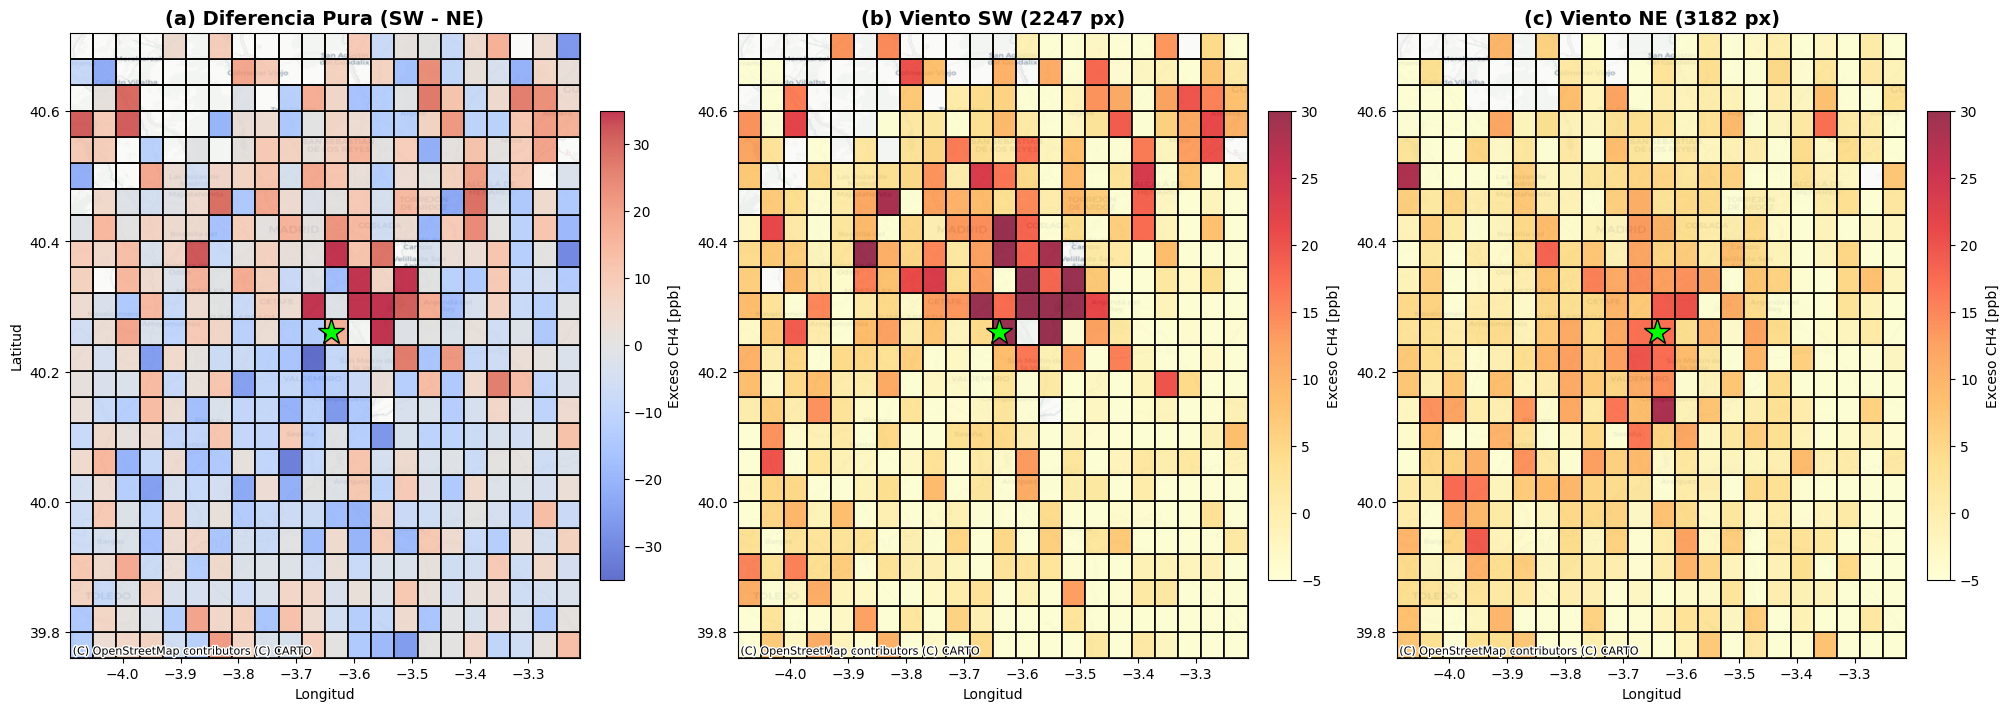

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN = -5     # Dejamos espacio para los valores negativos (aire limpio)
VMAX = 30      # Techo de color para la pluma

RESOLUCION = 0.04
QA_VALUE = 0.5
VIENTO_MIN = 0.5 # m/s
VIENTO_MAX = 5 # m/s

LAT_CENTRO, LON_CENTRO = 40.2606, -3.6406

# ==============================================================================
# 1. CARGA Y UNIÓN DE DATOS (ENERO A ABRIL)
# ==============================================================================
ARCHIVO_ENE = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_01.csv"
ARCHIVO_FEB = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_02.csv"
ARCHIVO_MAR = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_03.csv"
ARCHIVO_ABR = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_04.csv"
ARCHIVO_MAY = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_05.csv"
ARCHIVO_JUN = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_06.csv"



print("Cargando y uniendo los datos de los 4 meses...")

# Leemos los meses
df_ene = pd.read_csv(ARCHIVO_ENE)
df_feb = pd.read_csv(ARCHIVO_FEB)
df_mar = pd.read_csv(ARCHIVO_MAR)
df_abr = pd.read_csv(ARCHIVO_ABR)
df_may = pd.read_csv(ARCHIVO_MAY)
df_jun = pd.read_csv(ARCHIVO_JUN)


# Unimos las tablas en una sola
df = pd.concat([df_ene, df_feb, df_mar, df_abr, df_may, df_jun], ignore_index=True)

# Filtros de calidad y viento
df = df[(df['qa_value'] > QA_VALUE) & (df['v_modulo'] >= VIENTO_MIN) & (df['v_modulo'] <= VIENTO_MAX)].copy()

# Calculamos dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# Separación en los tres grupos
df_all = df.copy()
mask_sw = (df['dir_viento'] >= 135) & (df['dir_viento'] <= 315)
df_sw = df[mask_sw].copy()
df_ne = df[~mask_sw].copy()

print(f"Total píxeles válidos (4 meses): {len(df_all)}")
print(f" -> Viento SW: {len(df_sw)}")
print(f" -> Viento NE: {len(df_ne)}")

# ==============================================================================
# 2. OVERSAMPLING Y CORRECCIÓN DE FONDO (MÉTODO DEL ANILLO)
# ==============================================================================
lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

# Leemos el metano absoluto crudo (metano_ppb)
def hacer_oversampling(datos_df, variable='metano_ppb'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

# 1. Calculamos las matrices con el Metano Total absoluto
mapa_all_bruto = hacer_oversampling(df_all)
mapa_sw_bruto = hacer_oversampling(df_sw)
mapa_ne_bruto = hacer_oversampling(df_ne)

# -------------------------------------------------------------------
# ✨ EL MÉTODO DEL ANILLO (BACKGROUND RING) ✨
# -------------------------------------------------------------------
# A. Sacamos las coordenadas centrales de cada cuadradito
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

# B. Creamos una malla con todas las coordenadas X e Y
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

# C. Calculamos la distancia de cada celda al vertedero (Pitágoras)
distancia = np.sqrt((lon_grid - LON_CENTRO)**2 + (lat_grid - LAT_CENTRO)**2)

# D. Máscara del Donut: Usamos solo píxeles entre 0.2 y 0.4 grados de distancia
mask_anillo = (distancia >= 0.2) & (distancia <= 0.4)

# E. Calculamos el fondo exacto usando la mediana de ESE anillo
fondo_all = np.nanmedian(mapa_all_bruto[mask_anillo])
fondo_sw  = np.nanmedian(mapa_sw_bruto[mask_anillo])
fondo_ne  = np.nanmedian(mapa_ne_bruto[mask_anillo])

# F. Restamos el fondo a los mapas crudos para obtener la Anomalía Pura
mapa_all = mapa_all_bruto - fondo_all
mapa_sw  = mapa_sw_bruto - fondo_sw
mapa_ne  = mapa_ne_bruto - fondo_ne

# ==============================================================================
# 3. VISUALIZACIÓN EN 3 PANELES (Con Diferencia SW - NE)
# ==============================================================================
# Calculamos tu genial idea: La diferencia entre vientos opuestos
mapa_diff = mapa_sw - mapa_ne

fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Personalizamos cada gráfica porque la de diferencia necesita colores distintos
graficas = [
    {
        "ax": axes[0], "mapa": mapa_diff,
        "titulo": f"(a) Diferencia Pura (SW - NE)",
        "cmap": "coolwarm", "vmin": -35, "vmax": 35  # Límite simétrico para ver el dipolo
    },
    {
        "ax": axes[1], "mapa": mapa_sw,
        "titulo": f"(b) Viento SW ({len(df_sw)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX   # Fondo a 0 para ver solo la pluma
    },
    {
        "ax": axes[2], "mapa": mapa_ne,
        "titulo": f"(c) Viento NE ({len(df_ne)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    }
]

for g in graficas:
    ax = g["ax"]
    mapa = g["mapa"]

    # Ocultamos los NaN para no pintarlos
    mapa_visual = np.where(np.isnan(mapa), np.nan, mapa)

    # Usamos los parámetros específicos de cada diccionario
    mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap=g["cmap"],
                         vmin=g["vmin"], vmax=g["vmax"], shading='flat',
                         alpha=0.8, edgecolor='black', linewidth=0.1)

    # Estrella de la fuente (Valdemingómez)
    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
            markeredgecolor='black', label="Valdemingómez")

    # Mapa base
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

    ax.set_title(g["titulo"], fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitud")
    if g["ax"] == axes[0]:
        ax.set_ylabel("Latitud")

    # Barra de color
    plt.colorbar(mesh, ax=ax, label='Exceso CH4 [ppb]', fraction=0.046, pad=0.04)

plt.show()

# CON 1.5SIGMA, 2SIGMA, 2.5SIGMA (METODO ELEGIDO PARA CUANTIFICAR)

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...


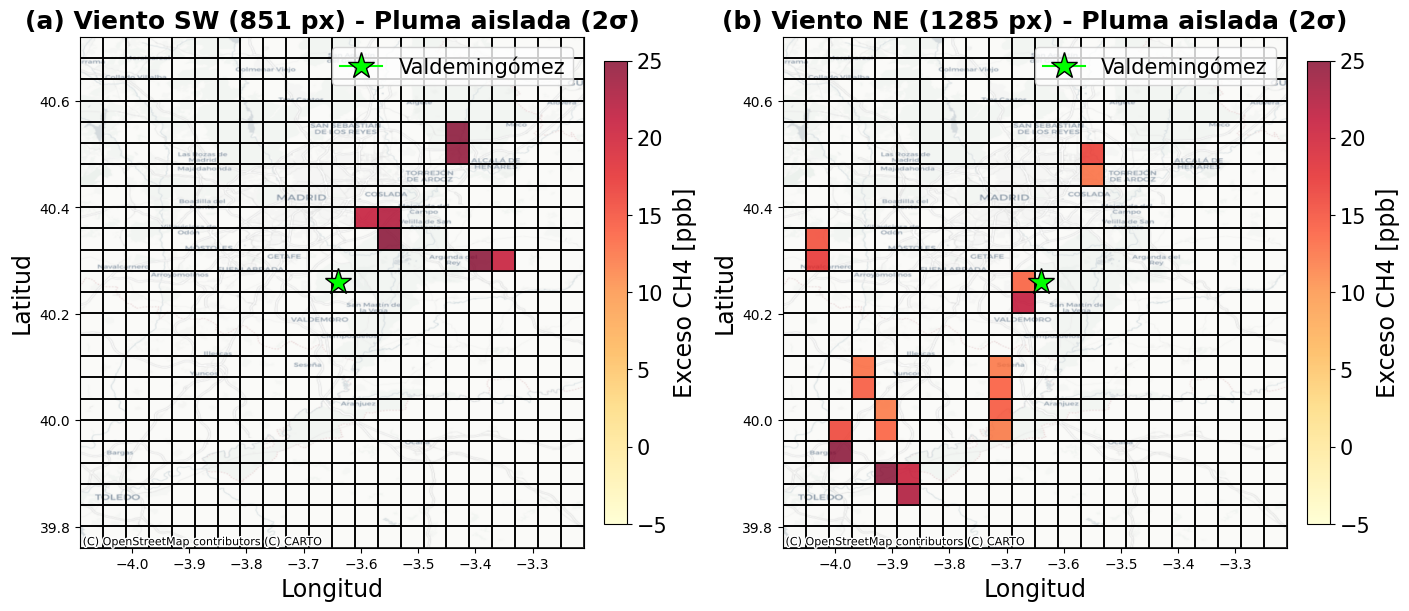


 RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME) Y ERRORES
📍 Régimen Suroeste (SW)
   Viento medio original (U10): 2.87 m/s
   Viento Efectivo (U_eff): 1.65 m/s
   -- Análisis de Sensibilidad (Flujos extraídos):
      Q (1.5σ): 11.83 t/h
      Q (2.0σ): 7.93 t/h
      Q (2.5σ): 0.00 t/h
   Incertidumbre viento (ε_Ueff): 31.6%
   Incertidumbre segmentación (ε_seg): 19.7%
   ➡️ TASA DE EMISIÓN MEDIA: 9.88 ± 3.68 t/h
      (Error relativo total: 37.2%)

📍 Régimen Noreste (NE)
   Viento medio original (U10): 3.35 m/s
   Viento Efectivo (U_eff): 1.81 m/s
   -- Análisis de Sensibilidad (Flujos extraídos):
      Q (1.5σ): 11.14 t/h
      Q (2.0σ): 9.78 t/h
      Q (2.5σ): 7.51 t/h
   Incertidumbre viento (ε_Ueff): 24.8%
   Incertidumbre segmentación (ε_seg): 15.8%
   ➡️ TASA DE EMISIÓN MEDIA: 9.48 ± 2.78 t/h
      (Error relativo total: 29.4%)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d
from scipy import ndimage # IMPRESCINDIBLE PARA AISLAR LA PLUMA

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = -5, 25
RESOLUCION = 0.04
QA_VALUE = 0.3
VIENTO_MIN, VIENTO_MAX = 2, 5
LAT_CENTRO, LON_CENTRO = 40.2606, -3.6406

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 10

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

# Definimos las rutas de los 13 meses
ARCHIVO_ENE_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_01.csv"
ARCHIVO_FEB_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_02.csv"
ARCHIVO_MAR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_03.csv"
ARCHIVO_ABR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_04.csv"
ARCHIVO_MAY_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_05.csv"
ARCHIVO_JUN_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_06.csv"
ARCHIVO_JUL_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_07.csv"

ARCHIVO_ENE_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_01.csv"
ARCHIVO_FEB_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_02.csv"
ARCHIVO_MAR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_03.csv"
ARCHIVO_ABR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_04.csv"
ARCHIVO_MAY_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_05.csv"
ARCHIVO_JUN_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_06.csv"

archivos = [ARCHIVO_ENE_19, ARCHIVO_FEB_19, ARCHIVO_MAR_19, ARCHIVO_ABR_19,
            ARCHIVO_MAY_19, ARCHIVO_JUN_19, ARCHIVO_JUL_19, ARCHIVO_ENE_23,
            ARCHIVO_FEB_23, ARCHIVO_MAR_23, ARCHIVO_ABR_23, ARCHIVO_MAY_23, ARCHIVO_JUN_23]

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

mask_barlovento = diferencia_angular > 90
mask_anillo_limpio = (df['distancia'] >= 0.2) & (df['distancia'] <= 0.4) & mask_barlovento

fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 3. SEPARACIÓN POR PASILLO DE VIENTO Y OVERSAMPLING
# ==============================================================================
df_sw = df[(df['dir_viento'] >= 200) & (df['dir_viento'] <= 250)].copy()
df_ne = df[(df['dir_viento'] >= 20)  & (df['dir_viento'] <= 70)].copy()

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

mapa_sw_bruto = hacer_oversampling(df_sw)
mapa_ne_bruto = hacer_oversampling(df_ne)

def aislar_pluma_cruda(mapa, umbral_ppb, min_pixeles=2):
    mascara_alta = (mapa > umbral_ppb) & (~np.isnan(mapa))
    etiquetas, num_grupos = ndimage.label(mascara_alta)
    tamanos = np.bincount(etiquetas.ravel())
    if len(tamanos) > 0:
        tamanos[0] = 0
    grupos_validos = np.where(tamanos >= min_pixeles)[0]
    mascara_final = np.isin(etiquetas, grupos_validos)

    mapa_limpio = np.copy(mapa)
    mapa_limpio[~mascara_final] = np.nan
    return mapa_limpio
# --- CÁLCULO DE 1.5, 2.0 Y 2.5 SIGMA ---
fondo_sw = mapa_sw_bruto[mapa_sw_bruto < np.nanpercentile(mapa_sw_bruto, 75)]
fondo_ne = mapa_ne_bruto[mapa_ne_bruto < np.nanpercentile(mapa_ne_bruto, 75)]

sigma_sw = np.nanstd(fondo_sw)
sigma_ne = np.nanstd(fondo_ne)

# Mapas SW
mapa_sw_1_5s = aislar_pluma_cruda(mapa_sw_bruto, umbral_ppb=1.5*sigma_sw, min_pixeles=2)
mapa_sw_2s   = aislar_pluma_cruda(mapa_sw_bruto, umbral_ppb=2.0*sigma_sw, min_pixeles=2)
mapa_sw_2_5s = aislar_pluma_cruda(mapa_sw_bruto, umbral_ppb=2.5*sigma_sw, min_pixeles=2)

# Mapas NE
mapa_ne_1_5s = aislar_pluma_cruda(mapa_ne_bruto, umbral_ppb=1.5*sigma_ne, min_pixeles=2)
mapa_ne_2s   = aislar_pluma_cruda(mapa_ne_bruto, umbral_ppb=2.0*sigma_ne, min_pixeles=2)
mapa_ne_2_5s = aislar_pluma_cruda(mapa_ne_bruto, umbral_ppb=2.5*sigma_ne, min_pixeles=2)

# ==============================================================================
# 4. VISUALIZACIÓN (SEGUIMOS MOSTRANDO 2 SIGMA POR CLARIDAD VISUAL)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

graficas = [
    {
        "ax": axes[0], "mapa": mapa_sw_2s,  # Mostramos el término medio
        "titulo": f"(a) Viento SW ({len(df_sw)} px) - Pluma aislada (2\u03C3)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    },
    {
        "ax": axes[1], "mapa": mapa_ne_2s,
        "titulo": f"(b) Viento NE ({len(df_ne)} px) - Pluma aislada (2\u03C3)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    }
]

for g in graficas:
    ax = g["ax"]
    mapa = g["mapa"]

    mapa_visual = np.where(np.isnan(mapa), np.nan, mapa)

    mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap=g["cmap"],
                         vmin=g["vmin"], vmax=g["vmax"], shading='flat',
                         alpha=0.8, edgecolor='black', linewidth=0.1)

    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
            markeredgecolor='black', label="Valdemingómez")

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

    ax.set_title(g["titulo"], fontsize=18, fontweight='bold')
    ax.set_xlabel("Longitud", fontsize=17)
    ax.set_ylabel("Latitud", fontsize=17)
    ax.legend(fontsize=15, loc='upper right')

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Exceso CH4 [ppb]', fontsize=17)
    cbar.ax.tick_params(labelsize=15)

plt.show()

# ==============================================================================
# 5. CUANTIFICACIÓN CON MÉTODO IME (1, 2 y 3 SIGMA)
# ==============================================================================
print("\n" + "="*60)
print(" RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME) Y ERRORES")
print("="*60)

M_CH4 = 0.01604
M_AIRE = 0.02896
G = 9.81
PRESION_MADRID = 94000

ALPHA_1 = 1.0
ALPHA_2 = 0.6
SIGMA_U10 = 1.5

columna_aire_mol = PRESION_MADRID / (M_AIRE * G)
largo_px = RESOLUCION * 111320
ancho_px = RESOLUCION * 111320 * np.cos(np.radians(LAT_CENTRO))
area_px = largo_px * ancho_px

def calcular_parametros_ime(mapa_pluma, U_eff):
    pixeles_validos = mapa_pluma[~np.isnan(mapa_pluma)]
    if len(pixeles_validos) == 0:
        return 0, 0, 0

    masa_kg_m2 = pixeles_validos * 1e-9 * columna_aire_mol * M_CH4
    ime_kg = np.sum(masa_kg_m2 * area_px)
    area_total = len(pixeles_validos) * area_px
    L = np.sqrt(area_total)

    tau = L / U_eff if U_eff > 0 else np.inf
    emision_kg_s = ime_kg / tau
    return emision_kg_s, ime_kg, area_total

def calcular_emision_ime_con_error(mapa_1_5s, mapa_2s, mapa_2_5s, df_viento, nombre):
    if len(df_viento) == 0:
        return

    V_media = df_viento['v_modulo'].mean()
    U_eff = ALPHA_1 * np.log(V_media) + ALPHA_2

    # Calculamos flujos para los 3 niveles
    Q_1_5s_kg_s, _, _ = calcular_parametros_ime(mapa_1_5s, U_eff)
    Q_2s_kg_s, ime_2s, area_2s = calcular_parametros_ime(mapa_2s, U_eff)
    Q_2_5s_kg_s, _, _ = calcular_parametros_ime(mapa_2_5s, U_eff)

    emisiones_kg_s = [q for q in [Q_1_5s_kg_s, Q_2s_kg_s, Q_2_5s_kg_s] if q > 0]

    if len(emisiones_kg_s) == 0:
         print(f"[{nombre}] No hay pluma aislada válida en ningún umbral.")
         return

    # Error del viento
    sigma_Ueff = (ALPHA_1 / V_media) * SIGMA_U10
    eps_Ueff = sigma_Ueff / U_eff

    # Error de segmentación robusto (Desviación estándar de los 3 escenarios)
    Q_media_kg_s = np.mean(emisiones_kg_s)

    if len(emisiones_kg_s) > 1:
        sigma_seg = np.std(emisiones_kg_s)
        eps_seg = sigma_seg / Q_media_kg_s
    else:
        eps_seg = 0

    eps_Q = np.sqrt(eps_seg**2 + eps_Ueff**2)

    emision_media_th = Q_media_kg_s * 3.6
    incertidumbre_th = emision_media_th * eps_Q

    print(f"📍 {nombre}")
    print(f"   Viento medio original (U10): {V_media:.2f} m/s")
    print(f"   Viento Efectivo (U_eff): {U_eff:.2f} m/s")
    print(f"   -- Análisis de Sensibilidad (Flujos extraídos):")
    print(f"      Q (1.5\u03C3): {Q_1_5s_kg_s * 3.6:.2f} t/h")
    print(f"      Q (2.0\u03C3): {Q_2s_kg_s * 3.6:.2f} t/h")
    print(f"      Q (2.5\u03C3): {Q_2_5s_kg_s * 3.6:.2f} t/h")
    print(f"   Incertidumbre viento (\u03B5_Ueff): {eps_Ueff*100:.1f}%")
    print(f"   Incertidumbre segmentación (\u03B5_seg): {eps_seg*100:.1f}%")
    print(f"   ➡️ TASA DE EMISIÓN MEDIA: {emision_media_th:.2f} ± {incertidumbre_th:.2f} t/h")
    print(f"      (Error relativo total: {eps_Q*100:.1f}%)\n")

# Ejecutamos con los tres mapas nuevos
calcular_emision_ime_con_error(mapa_sw_1_5s, mapa_sw_2s, mapa_sw_2_5s, df_sw, "Régimen Suroeste (SW)")
calcular_emision_ime_con_error(mapa_ne_1_5s, mapa_ne_2s, mapa_ne_2_5s, df_ne, "Régimen Noreste (NE)")

# CON 2SIGMA, 3 SIGMA (DESCARTADO, MUCHO ERROR)

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...


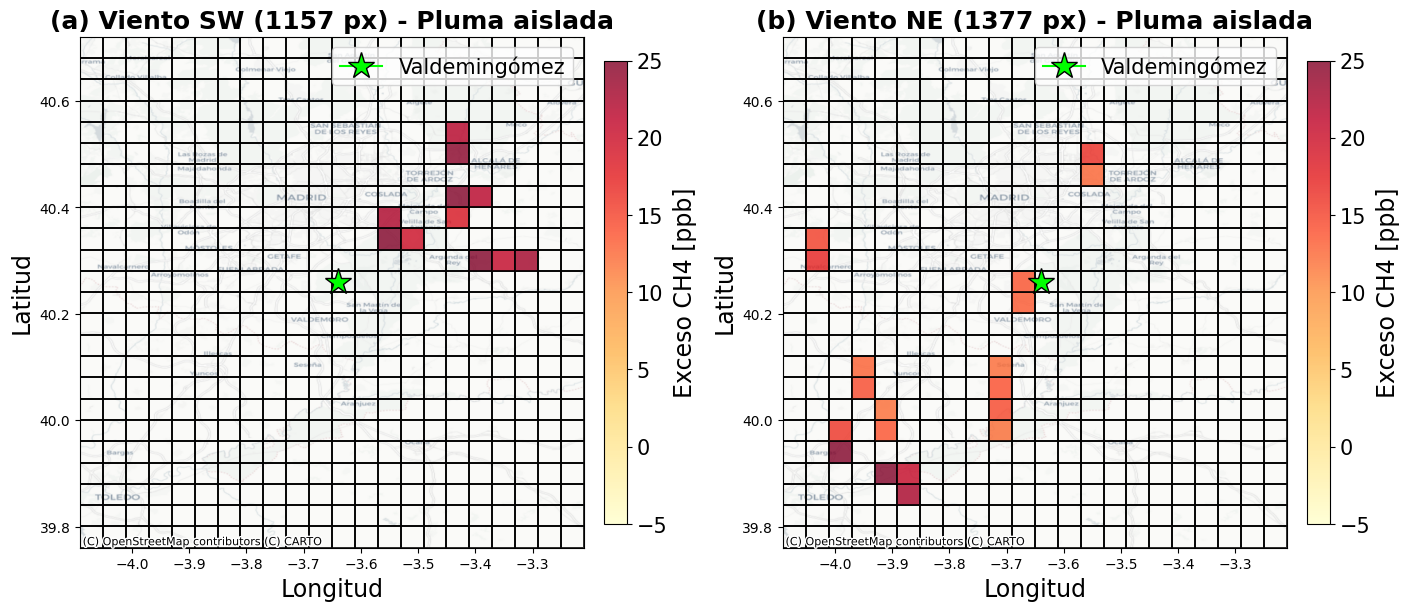

¡Visualización de vientos completada!

 RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME) Y ERRORES
📍 Régimen Suroeste (SW)
   Viento Efectivo (U_eff): 1.85 m/s
   Incertidumbre viento (ε_Ueff): 23.4%
   Incertidumbre segmentación (ε_seg): 141.4%
   Área promedio de la pluma: 83.22 km²
   Masa promedio de Metano (IME): 10488.75 kg
   ➡️ TASA DE EMISIÓN MEDIA: 5.40 ± 7.75 t/h
      (Error relativo total: 143.3%)

📍 Régimen Noreste (NE)
   Viento Efectivo (U_eff): 1.85 m/s
   Incertidumbre viento (ε_Ueff): 23.2%
   Incertidumbre segmentación (ε_seg): 40.4%
   Área promedio de la pluma: 166.44 km²
   Masa promedio de Metano (IME): 15173.47 kg
   ➡️ TASA DE EMISIÓN MEDIA: 7.60 ± 3.54 t/h
      (Error relativo total: 46.6%)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = -5, 25
RESOLUCION = 0.04
QA_VALUE = 0.3
VIENTO_MIN, VIENTO_MAX = 2, 6
LAT_CENTRO, LON_CENTRO = 40.2606, -3.6406

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 10

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

# Definimos las rutas de los 13 meses
ARCHIVO_ENE_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_01.csv"
ARCHIVO_FEB_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_02.csv"
ARCHIVO_MAR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_03.csv"
ARCHIVO_ABR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_04.csv"
ARCHIVO_MAY_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_05.csv"
ARCHIVO_JUN_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_06.csv"
ARCHIVO_JUL_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_07.csv"

ARCHIVO_ENE_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_01.csv"
ARCHIVO_FEB_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_02.csv"
ARCHIVO_MAR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_03.csv"
ARCHIVO_ABR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_04.csv"
ARCHIVO_MAY_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_05.csv"
ARCHIVO_JUN_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_06.csv"

archivos = [ARCHIVO_ENE_19, ARCHIVO_FEB_19, ARCHIVO_MAR_19, ARCHIVO_ABR_19,
            ARCHIVO_MAY_19, ARCHIVO_JUN_19, ARCHIVO_JUL_19, ARCHIVO_ENE_23,
            ARCHIVO_FEB_23, ARCHIVO_MAR_23, ARCHIVO_ABR_23, ARCHIVO_MAY_23, ARCHIVO_JUN_23]

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO / UPWIND BACKGROUND)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

# A. Dirección en la que está CADA PÍXEL respecto al centro (Valdemingómez)
# np.arctan2(y, x) -> y = latitud, x = longitud
df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360

# B. En meteorología, u10 y v10 dan la dirección HACIA DONDE va el viento
# Calculamos hacia dónde va la pluma
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

# C. Calculamos la diferencia de ángulo entre el píxel y la dirección de la pluma
# Queremos píxeles que estén en dirección contraria (una diferencia > 90º y < 270º)
diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
# Normalizamos la diferencia para que siempre esté entre 0 y 180
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

# D. LA MAGIA: El píxel es "Aire Limpio" si está a más de 90 grados de la pluma (semicírculo trasero)
mask_barlovento = diferencia_angular > 90

# E. Definimos el anillo SOLO en el área de barlovento
mask_anillo_limpio = (df['distancia'] >= 0.2) & (df['distancia'] <= 0.4) & mask_barlovento

# F. Calculamos la mediana del anillo limpio para cada día
fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()

# Si algún día no hay datos suficientes en barlovento, usamos la mediana global del día como red
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

# G. Restamos el fondo impoluto del día a cada píxel
df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# Asegúrate de tener este import al principio del todo:
# from scipy import ndimage

# ==============================================================================
# 3. SEPARACIÓN POR PASILLO DE VIENTO Y OVERSAMPLING
# ==============================================================================
# Pasillos estrictos
df_sw = df[(df['dir_viento'] >= 200) & (df['dir_viento'] <= 250)].copy()
df_ne = df[(df['dir_viento'] >= 20)  & (df['dir_viento'] <= 70)].copy()

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

# Mapas en crudo
mapa_sw_bruto = hacer_oversampling(df_sw)
mapa_ne_bruto = hacer_oversampling(df_ne)

# --- FUNCIÓN PARA AISLAR LA PLUMA (RESPETANDO LOS PÍXELES CRUDOS) ---
def aislar_pluma_cruda(mapa, umbral_ppb, min_pixeles=2):
    # En mapas sin suavizar, exigimos menos píxeles juntos (ej. 2) porque es más fácil que se desconecten
    mascara_alta = (mapa > umbral_ppb) & (~np.isnan(mapa))
    etiquetas, num_grupos = ndimage.label(mascara_alta)
    tamanos = np.bincount(etiquetas.ravel())
    if len(tamanos) > 0:
        tamanos[0] = 0
    grupos_validos = np.where(tamanos >= min_pixeles)[0]
    mascara_final = np.isin(etiquetas, grupos_validos)

    mapa_limpio = np.copy(mapa)
    mapa_limpio[~mascara_final] = np.nan
    return mapa_limpio

# --- CÁLCULO DEL RUIDO Y FILTRADO ESPACIAL ---
fondo_sw = mapa_sw_bruto[mapa_sw_bruto < np.nanpercentile(mapa_sw_bruto, 75)]
fondo_ne = mapa_ne_bruto[mapa_ne_bruto < np.nanpercentile(mapa_ne_bruto, 75)]

sigma_sw = np.nanstd(fondo_sw)
sigma_ne = np.nanstd(fondo_ne)

UMBRAL_SW_2S = 2 * sigma_sw
UMBRAL_SW_3S = 3 * sigma_sw
UMBRAL_NE_2S = 2 * sigma_ne
UMBRAL_NE_3S = 3 * sigma_ne

# Filtramos aislando solo los bloques de metano real
mapa_sw_2s = aislar_pluma_cruda(mapa_sw_bruto, umbral_ppb=UMBRAL_SW_2S, min_pixeles=2)
mapa_sw_3s = aislar_pluma_cruda(mapa_sw_bruto, umbral_ppb=UMBRAL_SW_3S, min_pixeles=2)

mapa_ne_2s = aislar_pluma_cruda(mapa_ne_bruto, umbral_ppb=UMBRAL_NE_2S, min_pixeles=2)
mapa_ne_3s = aislar_pluma_cruda(mapa_ne_bruto, umbral_ppb=UMBRAL_NE_3S, min_pixeles=2)

# ==============================================================================
# 4. VISUALIZACIÓN (SOLO VIENTOS SW Y NE - FILTRADOS A 2 SIGMA)
# ==============================================================================
# Creamos una figura con solo 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Usamos los mapas filtrados para visualizar qué estamos cuantificando realmente
graficas = [
    {
        "ax": axes[0], "mapa": mapa_sw_2s,
        "titulo": f"(a) Viento SW ({len(df_sw)} px) - Pluma aislada",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    },
    {
        "ax": axes[1], "mapa": mapa_ne_2s,
        "titulo": f"(b) Viento NE ({len(df_ne)} px) - Pluma aislada",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    }
]

for g in graficas:
    ax = g["ax"]
    mapa = g["mapa"]

    mapa_visual = np.where(np.isnan(mapa), np.nan, mapa)

    # Dibujamos el raster con shading='flat' y bordes negros (tu estilo)
    mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap=g["cmap"],
                         vmin=g["vmin"], vmax=g["vmax"], shading='flat',
                         alpha=0.8, edgecolor='black', linewidth=0.1)

    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
            markeredgecolor='black', label="Valdemingómez")

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

    # --- AJUSTES DE TAMAÑO DE LETRA ---
    ax.set_title(g["titulo"], fontsize=18, fontweight='bold')
    ax.set_xlabel("Longitud", fontsize=17)
    ax.set_ylabel("Latitud", fontsize=17)
    ax.legend(fontsize=15, loc='upper right')

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Exceso CH4 [ppb]', fontsize=17)
    cbar.ax.tick_params(labelsize=15)

plt.show()
print("¡Visualización de vientos completada!")

# ==============================================================================
# 5. CUANTIFICACIÓN CON MÉTODO IME Y PROPAGACIÓN DE ERRORES
# ==============================================================================
print("\n" + "="*60)
print(" RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME) Y ERRORES")
print("="*60)

M_CH4 = 0.01604
M_AIRE = 0.02896
G = 9.81
PRESION_MADRID = 94000

ALPHA_1 = 1.0
ALPHA_2 = 0.6
SIGMA_U10 = 1.5

columna_aire_mol = PRESION_MADRID / (M_AIRE * G)
largo_px = RESOLUCION * 111320
ancho_px = RESOLUCION * 111320 * np.cos(np.radians(LAT_CENTRO))
area_px = largo_px * ancho_px

def calcular_parametros_ime(mapa_pluma, U_eff):
    pixeles_validos = mapa_pluma[~np.isnan(mapa_pluma)]
    if len(pixeles_validos) == 0:
        return 0, 0, 0

    masa_kg_m2 = pixeles_validos * 1e-9 * columna_aire_mol * M_CH4
    ime_kg = np.sum(masa_kg_m2 * area_px)
    area_total = len(pixeles_validos) * area_px
    L = np.sqrt(area_total)

    tau = L / U_eff if U_eff > 0 else np.inf
    emision_kg_s = ime_kg / tau
    return emision_kg_s, ime_kg, area_total

def calcular_emision_ime_con_error(mapa_2sigma, mapa_3sigma, df_viento, nombre):
    if len(df_viento) == 0:
        return

    V_media = df_viento['v_modulo'].mean()
    U_eff = ALPHA_1 * np.log(V_media) + ALPHA_2

    Q_2s_kg_s, ime_2s, area_2s = calcular_parametros_ime(mapa_2sigma, U_eff)
    Q_3s_kg_s, ime_3s, area_3s = calcular_parametros_ime(mapa_3sigma, U_eff)

    if Q_2s_kg_s == 0 and Q_3s_kg_s == 0:
         print(f"[{nombre}] No hay pluma aislada válida en ningún umbral para calcular.")
         return

    sigma_Ueff = (ALPHA_1 / V_media) * SIGMA_U10
    eps_Ueff = sigma_Ueff / U_eff

    Q_media_kg_s = (Q_2s_kg_s + Q_3s_kg_s) / 2
    if Q_media_kg_s > 0:
        sigma_seg = abs(Q_2s_kg_s - Q_3s_kg_s) / np.sqrt(2)
        eps_seg = sigma_seg / Q_media_kg_s
    else:
        eps_seg = 0

    eps_Q = np.sqrt(eps_seg**2 + eps_Ueff**2)

    emision_media_th = Q_media_kg_s * 3.6
    incertidumbre_th = emision_media_th * eps_Q

    print(f"📍 {nombre}")
    print(f"   Viento Efectivo (U_eff): {U_eff:.2f} m/s")
    print(f"   Incertidumbre viento (\u03B5_Ueff): {eps_Ueff*100:.1f}%")
    print(f"   Incertidumbre segmentación (\u03B5_seg): {eps_seg*100:.1f}%")
    print(f"   Área promedio de la pluma: {((area_2s + area_3s)/2) / 1e6:.2f} km²")
    print(f"   Masa promedio de Metano (IME): {(ime_2s + ime_3s)/2:.2f} kg")
    print(f"   ➡️ TASA DE EMISIÓN MEDIA: {emision_media_th:.2f} ± {incertidumbre_th:.2f} t/h")
    print(f"      (Error relativo total: {eps_Q*100:.1f}%)\n")

calcular_emision_ime_con_error(mapa_sw_2s, mapa_sw_3s, df_sw, "Régimen Suroeste (SW)")
calcular_emision_ime_con_error(mapa_ne_2s, mapa_ne_3s, df_ne, "Régimen Noreste (NE)")

# DIFUMINADO

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...
3. Separando vientos y calculando matrices espaciales...


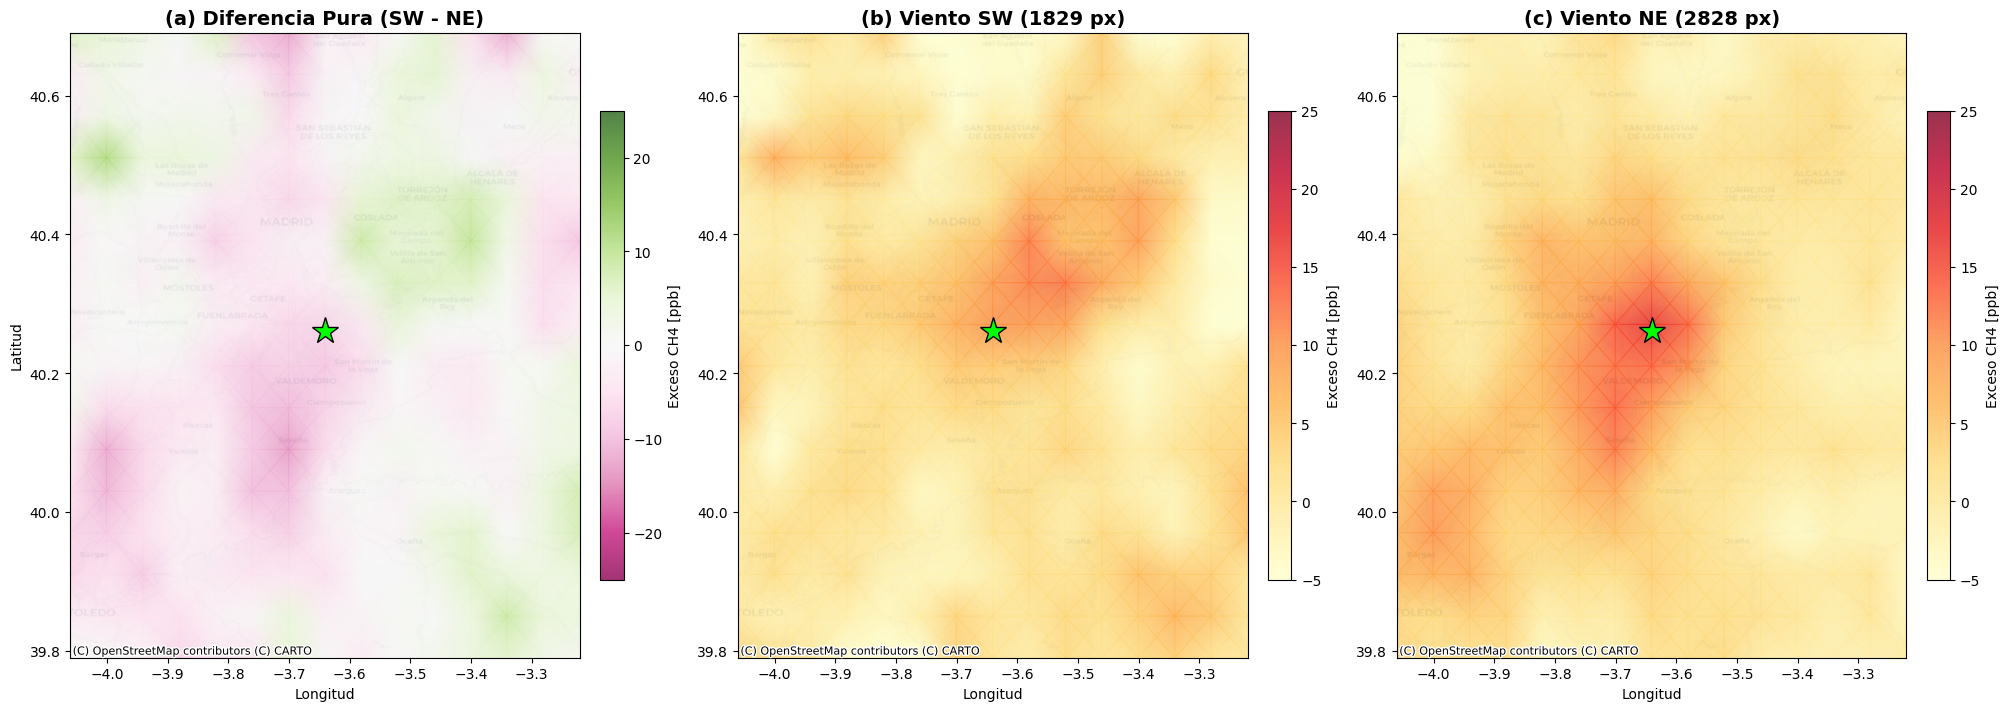

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = -5, 25
RESOLUCION = 0.06
QA_VALUE = 0.3
VIENTO_MIN, VIENTO_MAX = 0.5, 4
LAT_CENTRO, LON_CENTRO = 40.2606, -3.6406

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 10

SUAVIZADO = 0.6

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

# Definimos las rutas de los 13 meses
ARCHIVO_ENE_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_01.csv"
ARCHIVO_FEB_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_02.csv"
ARCHIVO_MAR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_03.csv"
ARCHIVO_ABR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_04.csv"
ARCHIVO_MAY_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_05.csv"
ARCHIVO_JUN_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_06.csv"
ARCHIVO_JUL_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_07.csv"

ARCHIVO_ENE_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_01.csv"
ARCHIVO_FEB_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_02.csv"
ARCHIVO_MAR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_03.csv"
ARCHIVO_ABR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_04.csv"
ARCHIVO_MAY_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_05.csv"
ARCHIVO_JUN_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_06.csv"

archivos = [ARCHIVO_ENE_19, ARCHIVO_FEB_19, ARCHIVO_MAR_19, ARCHIVO_ABR_19,
            ARCHIVO_MAY_19, ARCHIVO_JUN_19, ARCHIVO_JUL_19, ARCHIVO_ENE_23,
            ARCHIVO_FEB_23, ARCHIVO_MAR_23, ARCHIVO_ABR_23, ARCHIVO_MAY_23, ARCHIVO_JUN_23]

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO / UPWIND BACKGROUND)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

# A. Dirección en la que está CADA PÍXEL respecto al centro (Valdemingómez)
# np.arctan2(y, x) -> y = latitud, x = longitud
df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360

# B. En meteorología, u10 y v10 dan la dirección HACIA DONDE va el viento
# Calculamos hacia dónde va la pluma
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

# C. Calculamos la diferencia de ángulo entre el píxel y la dirección de la pluma
# Queremos píxeles que estén en dirección contraria (una diferencia > 90º y < 270º)
diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
# Normalizamos la diferencia para que siempre esté entre 0 y 180
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

# D. LA MAGIA: El píxel es "Aire Limpio" si está a más de 90 grados de la pluma (semicírculo trasero)
mask_barlovento = diferencia_angular > 90

# E. Definimos el anillo SOLO en el área de barlovento
mask_anillo_limpio = (df['distancia'] >= 0.2) & (df['distancia'] <= 0.4) & mask_barlovento

# F. Calculamos la mediana del anillo limpio para cada día
fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()

# Si algún día no hay datos suficientes en barlovento, usamos la mediana global del día como red
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

# G. Restamos el fondo impoluto del día a cada píxel
df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 3. SEPARACIÓN POR PASILLO ESTRICTO, OVERSAMPLING Y SUAVIZADO
# ==============================================================================
print("3. Separando vientos y calculando matrices espaciales...")

df_sw = df[(df['dir_viento'] >= 200) & (df['dir_viento'] <= 250)].copy()
df_ne = df[(df['dir_viento'] >= 20)  & (df['dir_viento'] <= 70)].copy()

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

# 🎨 NUEVO: FUNCIÓN PARA DIFUMINAR (FILTRO GAUSSIANO QUE RESPETA LOS NaN)
def suavizar_datos(mapa, radio=1.2):
    # Rellenamos los vacíos temporalmente para poder aplicar la matemática
    mapa_ceros = np.nan_to_num(mapa, nan=0.0)
    mascara = (~np.isnan(mapa)).astype(float)

    # Difuminamos la imagen y la máscara
    mapa_suave = ndimage.gaussian_filter(mapa_ceros, sigma=radio)
    mascara_suave = ndimage.gaussian_filter(mascara, sigma=radio)

    # Dividimos para recuperar el valor real
    with np.errstate(invalid='ignore', divide='ignore'):
        resultado = mapa_suave / mascara_suave

    # Volvemos a ocultar las zonas donde no había ni un solo dato cerca
    resultado[mascara_suave < 0.05] = np.nan
    return resultado

# Calculamos matrices en crudo (con cuadrados)
mapa_sw_bruto = hacer_oversampling(df_sw)
mapa_ne_bruto = hacer_oversampling(df_ne)

# Aplicamos la brocha (Puedes subir a 1.5 o 2.0 si lo quieres MÁS difuminado)
RADIO_SUAVIZADO = SUAVIZADO
mapa_sw = suavizar_datos(mapa_sw_bruto, radio=RADIO_SUAVIZADO)
mapa_ne = suavizar_datos(mapa_ne_bruto, radio=RADIO_SUAVIZADO)

# Calcular LA DIFERENCIA con los mapas ya suavizados
mapa_diff = mapa_sw - mapa_ne
# ==============================================================================
# 4. VISUALIZACIÓN
# ==============================================================================
# Calculamos tu genial idea: La diferencia entre vientos opuestos
mapa_diff = mapa_sw - mapa_ne

fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Personalizamos cada gráfica porque la de diferencia necesita colores distintos
graficas = [
    {
        "ax": axes[0], "mapa": mapa_diff,
        "titulo": f"(a) Diferencia Pura (SW - NE)",
        "cmap": "PiYG", "vmin": -25, "vmax": 25  # Límite simétrico para ver el dipolo
    },
    {
        "ax": axes[1], "mapa": mapa_sw,
        "titulo": f"(b) Viento SW ({len(df_sw)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX   # Fondo a 0 para ver solo la pluma
    },
    {
        "ax": axes[2], "mapa": mapa_ne,
        "titulo": f"(c) Viento NE ({len(df_ne)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    }
]

# 🎨 NUEVO: Sacamos los centros de las celdas para el gradiente suave
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

for g in graficas:
    ax = g["ax"]
    mapa = g["mapa"]

    # Ocultamos los NaN para no pintarlos
    mapa_visual = np.where(np.isnan(mapa), np.nan, mapa)

    # 🎨 CAMBIOS CLAVE AQUÍ: Usamos los centers, shading='gouraud' y sin líneas negras
    mesh = ax.pcolormesh(lon_centers, lat_centers, mapa_visual, cmap=g["cmap"],
                         vmin=g["vmin"], vmax=g["vmax"], shading='gouraud',
                         alpha=0.8)

    # Estrella de la fuente (Valdemingómez)
    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
            markeredgecolor='black', label="Valdemingómez")

    # Mapa base
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

    ax.set_title(g["titulo"], fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitud")
    if g["ax"] == axes[0]:
        ax.set_ylabel("Latitud")

    # Barra de color
    plt.colorbar(mesh, ax=ax, label='Exceso CH4 [ppb]', fraction=0.046, pad=0.04)

plt.show()

# PLUMA SUAVIZADA

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...
3. Separando vientos y calculando matrices espaciales...


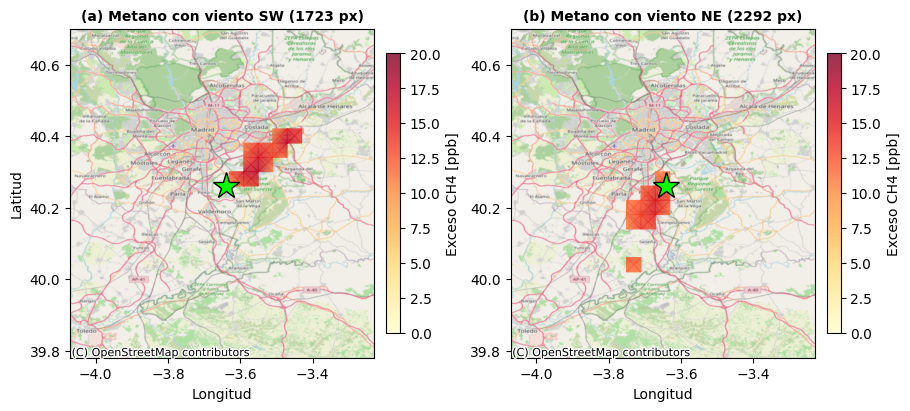

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = 0, 20
RESOLUCION = 0.04
QA_VALUE = 0.3
VIENTO_MIN, VIENTO_MAX = 1, 5
LAT_CENTRO, LON_CENTRO = 40.2606, -3.6406

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 10

SUAVIZADO = 0.6

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

# Definimos las rutas de los 13 meses
ARCHIVO_ENE_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_01.csv"
ARCHIVO_FEB_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_02.csv"
ARCHIVO_MAR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_03.csv"
ARCHIVO_ABR_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_04.csv"
ARCHIVO_MAY_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_05.csv"
ARCHIVO_JUN_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_06.csv"
ARCHIVO_JUL_19 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2019_07.csv"

ARCHIVO_ENE_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_01.csv"
ARCHIVO_FEB_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_02.csv"
ARCHIVO_MAR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_03.csv"
ARCHIVO_ABR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_04.csv"
ARCHIVO_MAY_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_05.csv"
ARCHIVO_JUN_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TROPOMI_ERA5/TROPOMI_Madrid_2023_06.csv"

archivos = [ARCHIVO_ENE_19, ARCHIVO_FEB_19, ARCHIVO_MAR_19, ARCHIVO_ABR_19,
            ARCHIVO_MAY_19, ARCHIVO_JUN_19, ARCHIVO_JUL_19, ARCHIVO_ENE_23,
            ARCHIVO_FEB_23, ARCHIVO_MAR_23, ARCHIVO_ABR_23, ARCHIVO_MAY_23, ARCHIVO_JUN_23]

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO / UPWIND BACKGROUND)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

# A. Dirección en la que está CADA PÍXEL respecto al centro (Valdemingómez)
# np.arctan2(y, x) -> y = latitud, x = longitud
df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360

# B. En meteorología, u10 y v10 dan la dirección HACIA DONDE va el viento
# Calculamos hacia dónde va la pluma
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

# C. Calculamos la diferencia de ángulo entre el píxel y la dirección de la pluma
# Queremos píxeles que estén en dirección contraria (una diferencia > 90º y < 270º)
diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
# Normalizamos la diferencia para que siempre esté entre 0 y 180
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

# D. LA MAGIA: El píxel es "Aire Limpio" si está a más de 90 grados de la pluma (semicírculo trasero)
mask_barlovento = diferencia_angular > 90

# E. Definimos el anillo SOLO en el área de barlovento
mask_anillo_limpio = (df['distancia'] >= 0.2) & (df['distancia'] <= 0.4) & mask_barlovento

# F. Calculamos la mediana del anillo limpio para cada día
fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()

# Si algún día no hay datos suficientes en barlovento, usamos la mediana global del día como red
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

# G. Restamos el fondo impoluto del día a cada píxel
df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 3. SEPARACIÓN POR PASILLO ESTRICTO, OVERSAMPLING Y SUAVIZADO
# ==============================================================================
print("3. Separando vientos y calculando matrices espaciales...")

df_sw = df[(df['dir_viento'] >= 200) & (df['dir_viento'] <= 250)].copy()
df_ne = df[(df['dir_viento'] >= 20)  & (df['dir_viento'] <= 70)].copy()

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

# 🎨 NUEVO: FUNCIÓN PARA DIFUMINAR (FILTRO GAUSSIANO QUE RESPETA LOS NaN)
def suavizar_datos(mapa, radio=1.2):
    # Rellenamos los vacíos temporalmente para poder aplicar la matemática
    mapa_ceros = np.nan_to_num(mapa, nan=0.0)
    mascara = (~np.isnan(mapa)).astype(float)

    # Difuminamos la imagen y la máscara
    mapa_suave = ndimage.gaussian_filter(mapa_ceros, sigma=radio)
    mascara_suave = ndimage.gaussian_filter(mascara, sigma=radio)

    # Dividimos para recuperar el valor real
    with np.errstate(invalid='ignore', divide='ignore'):
        resultado = mapa_suave / mascara_suave

    # Volvemos a ocultar las zonas donde no había ni un solo dato cerca
    resultado[mascara_suave < 0.05] = np.nan
    return resultado

# 🎨 NUEVO: FUNCIÓN PARA AISLAR LA PLUMA (ELIMINAR PÍXELES SUELTOS)
def aislar_pluma(mapa, umbral_ppb=15, min_pixeles=4):
    """
    Filtra el mapa dejando solo manchas continuas de valores altos.
    - umbral_ppb: Valor mínimo para considerar que hay pluma.
    - min_pixeles: Tamaño mínimo del grupo (mancha) para no ser borrado.
    """
    # 1. Crear una máscara binaria (True/False) de las zonas con emisión alta
    mascara_alta = (mapa > umbral_ppb) & (~np.isnan(mapa))

    # 2. Etiquetar grupos: ndimage.label busca píxeles True que estén tocándose
    # y les asigna un número (1 para el primer grupo, 2 para el segundo...)
    etiquetas, num_grupos = ndimage.label(mascara_alta)

    # 3. Contar cuántos píxeles tiene cada grupo
    tamanos = np.bincount(etiquetas.ravel())
    tamanos[0] = 0 # El grupo 0 es el fondo vacío, lo ignoramos

    # 4. Quedarnos solo con los grupos que tengan un tamaño >= min_pixeles
    grupos_validos = np.where(tamanos >= min_pixeles)[0]
    mascara_final = np.isin(etiquetas, grupos_validos)

    # 5. Aplicar la máscara: lo que no sea pluma validada, lo hacemos transparente (nan)
    mapa_limpio = np.copy(mapa)
    mapa_limpio[~mascara_final] = np.nan

    return mapa_limpio

# Calculamos matrices en crudo (con cuadrados)
mapa_sw_bruto = hacer_oversampling(df_sw)
mapa_ne_bruto = hacer_oversampling(df_ne)

# 1º Paso: Aplicamos la brocha para suavizar
RADIO_SUAVIZADO = 0.8  # Un poco más alto ayuda a conectar la pluma
mapa_sw_suave = suavizar_datos(mapa_sw_bruto, radio=RADIO_SUAVIZADO)
mapa_ne_suave = suavizar_datos(mapa_ne_bruto, radio=RADIO_SUAVIZADO)

# 2º Paso: Aislamos la pluma (Borramos el ruido)
# Ajusta el umbral (ej. 3 o 5 ppb) y los píxeles mínimos según veas tus datos
mapa_sw = aislar_pluma(mapa_sw_suave, umbral_ppb=10, min_pixeles=5)
mapa_ne = aislar_pluma(mapa_ne_suave, umbral_ppb=10, min_pixeles=5)

# Calcular LA DIFERENCIA con los mapas ya limpios
mapa_diff = mapa_sw - mapa_ne
# ==============================================================================
# 4. VISUALIZACIÓN (MODIFICADA: 2 COLUMNAS)
# ==============================================================================

# Creamos la figura con solo 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

# Definimos solo las dos gráficas de vientos
graficas = [
    {
        "ax": axes[0], "mapa": mapa_sw,
        "titulo": f"(a) Metano con viento SW ({len(df_sw)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    },
    {
        "ax": axes[1], "mapa": mapa_ne,
        "titulo": f"(b) Metano con viento NE ({len(df_ne)} px)",
        "cmap": "YlOrRd", "vmin": VMIN, "vmax": VMAX
    }
]

# Sacamos los centros de las celdas para el gradiente suave
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

for g in graficas:
    ax = g["ax"]
    mapa = g["mapa"]

    # Ocultamos los NaN para no pintarlos
    mapa_visual = np.where(np.isnan(mapa), np.nan, mapa)

    # Dibujamos el mapa con sombreado suave
    mesh = ax.pcolormesh(lon_centers, lat_centers, mapa_visual, cmap=g["cmap"],
                         vmin=g["vmin"], vmax=g["vmax"], shading='gouraud',
                         alpha=0.8)

    # Estrella de la fuente (Valdemingómez)
    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
            markeredgecolor='black', label="Valdemingómez")

    # Mapa base
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik)

    ax.set_title(g["titulo"], fontsize=10, fontweight='bold')
    ax.set_xlabel("Longitud")

    # Ponemos la etiqueta de Latitud solo en el eje de la izquierda (axes[0])
    if ax == axes[0]:
        ax.set_ylabel("Latitud")

    # Barra de color para cada gráfico
    plt.colorbar(mesh, ax=ax, label='Exceso CH4 [ppb]', fraction=0.046, pad=0.04)

plt.show()

# REPRESENTACIÓN PLUMA SUAVIZADA Y CUANTIFICACIÓN MEDIANTE MÉTODO IME